# 04 — Evaluation, thresholds, and the test set

Notebook 03 answered *which feature*. This one asks the harder questions:

1. Is the winner's margin **real**, or is it noise?
2. The 0.5 threshold is arbitrary. What threshold should an insurer actually use?
3. What does the single-feature constraint **cost** the client?
4. How does the recommendation hold up on data nothing has touched?

The test set is scored **once**, at the end. Every choice made before that point —
which feature, which encoding, which threshold — is made on validation.

In [1]:
import sys; sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.metrics import roc_curve, precision_recall_curve

from src import config as cfg
from src.data import load_raw, split_data, majority_class_baseline
from src.features import MedianImputer, build_design
from src.evaluate import classification_metrics, expected_cost
from src.plots import set_style, save_fig

set_style()
pd.set_option("display.width", 200)
rng = np.random.default_rng(cfg.SEED)

df = load_raw()
train, val, test = split_data(df)
imputer = MedianImputer().fit(train)
tr, va, te = imputer.transform(train), imputer.transform(val), imputer.transform(test)
baseline = majority_class_baseline(train[cfg.TARGET])
y_val = val[cfg.TARGET].to_numpy()


def fit_predict(features, target_df):
    """Fit on train, predict probabilities for target_df."""
    X_tr = sm.add_constant(build_design(tr, features, "dummy"))
    X = sm.add_constant(build_design(target_df, features, "dummy"), has_constant="add")[X_tr.columns]
    return sm.Logit(tr[cfg.TARGET], X_tr).fit(disp=0).predict(X).to_numpy()


TOP = ["driving_experience", "age", "income", "vehicle_ownership",
       "speeding_violations", "past_accidents"]
val_probs = {f: fit_predict([f], va) for f in TOP}
print(f"baseline {baseline:.4f} | validation n = {len(val)} | test n = {len(test)} (still untouched)")

baseline 0.6867 | validation n = 1500 | test n = 1500 (still untouched)


## 1. Is the winner's margin real?

`driving_experience` scored 78.80% and `age` scored 77.87% on validation. That is a gap
of 0.93 percentage points — about 14 customers out of 1,500. Before recommending one over
the other, it is worth asking whether a gap that size means anything.

A paired bootstrap resamples the validation set 10,000 times and refits nothing, so it
measures exactly the quantity in question: how much the comparison would move if we had
drawn a different 1,500 customers.

In [2]:
n = len(y_val)
idx = rng.integers(0, n, size=(10_000, n))

def boot_accuracy(p, threshold=0.5):
    pred = (p >= threshold).astype(int)
    correct = (pred == y_val).astype(float)
    return correct[idx].mean(axis=1)

boots = {f: boot_accuracy(p) for f, p in val_probs.items()}

ci = pd.DataFrame([{
    "feature": f,
    "accuracy": (val_probs[f] >= 0.5).astype(int).__eq__(y_val).mean(),
    "ci_low": np.percentile(b, 2.5),
    "ci_high": np.percentile(b, 97.5),
} for f, b in boots.items()]).sort_values("accuracy", ascending=False)
ci.round(4).reset_index(drop=True)

,feature,accuracy,ci_low,ci_high
0,driving_experience,0.7880,0.7673,0.8080
1,age,0.7787,0.7573,0.8000
2,income,0.7547,0.7326,0.7760
3,vehicle_ownership,0.7447,0.7227,0.7667
4,speeding_violations,0.6867,0.6627,0.7100
5,past_accidents,0.6867,0.6627,0.7100


In [3]:
# The comparison that matters: the gap between first and second place.
gap = boots["driving_experience"] - boots["age"]
print(f"driving_experience - age")
print(f"  observed gap        {ci.iloc[0].accuracy - ci.iloc[1].accuracy:+.4f}")
print(f"  95% CI              [{np.percentile(gap, 2.5):+.4f}, {np.percentile(gap, 97.5):+.4f}]")
print(f"  P(driving_experience is better) = {(gap > 0).mean():.4f}")
print()

lift = boots["driving_experience"] - baseline
print(f"driving_experience - baseline")
print(f"  95% CI              [{np.percentile(lift, 2.5):+.4f}, {np.percentile(lift, 97.5):+.4f}]")
print(f"  P(beats baseline)   = {(lift > 0).mean():.4f}")

driving_experience - age
  observed gap        +0.0093
  95% CI              [-0.0100, +0.0287]
  P(driving_experience is better) = 0.8238

driving_experience - baseline
  95% CI              [+0.0806, +0.1213]
  P(beats baseline)   = 1.0000


### Two findings, pulling in opposite directions

**The lift over baseline is unambiguous.** The 95% interval runs from +8.1 to +12.1
points and never approaches zero. In 10,000 resamples, `driving_experience` beat the
68.67% baseline every single time. There is real signal here.

**The gap to second place is not.** The interval for `driving_experience` minus `age`
runs from **−0.010 to +0.029**. It straddles zero. `driving_experience` came out ahead in
82% of resamples, which sounds reassuring until you notice that a fair coin clears 80%
about as often as this data distinguishes these two features.

So the correct statement is not "driving experience is the best predictor." It is:
**driving experience and age are statistically indistinguishable on this data, and both
clearly beat the baseline.**

This is exactly the nuance Session 1 anticipated. `age` spreads the outcome slightly
*wider* (0.627 vs 0.612), the two are structurally nested — a 16-25 year old cannot have
30 years of experience — and their Cramér's V is 0.668. Two features encoding largely the
same underlying fact should be hard to separate, and they are.

The reference reports `driving_experience` as *the* answer with no interval attached. It
picked the right neighbourhood and expressed more confidence than the data supports.

findfont: Failed to find font weight semibold, now using 700.


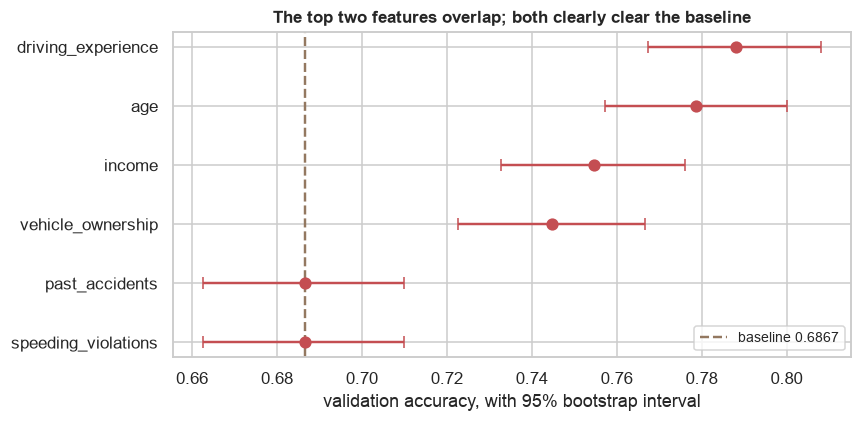

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
d = ci.sort_values("accuracy")
ax.errorbar(d.accuracy, d.feature,
            xerr=[d.accuracy - d.ci_low, d.ci_high - d.accuracy],
            fmt="o", color="#C44E52", capsize=4, markersize=7, lw=1.6)
ax.axvline(baseline, color="#937860", ls="--", lw=1.6, label=f"baseline {baseline:.4f}")
ax.set_xlabel("validation accuracy, with 95% bootstrap interval")
ax.set_title("The top two features overlap; both clearly clear the baseline", fontsize=11)
ax.legend(fontsize=9)
fig.tight_layout()
save_fig(fig, "accuracy_bootstrap_ci")
plt.show()

## 2. The 0.5 threshold is a choice nobody made

The reference classifies a customer as a claimant when the predicted probability exceeds
0.5. That is the library default, not a decision. It implicitly asserts that a missed
claim and a false alarm cost an insurer the same amount, which is not true of any
insurance business.

Let the cost of a **false negative** (a claim you did not see coming) be `r` times the
cost of a **false positive** (a good customer you wrongly flagged). `r` is a business
input, not something the data can tell us, so it is stated openly and varied.

In [5]:
thresholds = np.arange(0.02, 0.99, 0.01)
p_de = val_probs["driving_experience"]

rows = []
for r in [1, 2, 3, 5, 8, 10, 20]:
    costs = np.array([expected_cost(y_val, p_de, t, r) for t in thresholds])
    best = thresholds[costs.argmin()]
    m = classification_metrics(y_val, p_de, threshold=best)
    rows.append({"cost_ratio": f"{r}:1", "optimal_threshold": best,
                 "expected_cost": costs.min(), "recall": m["recall"],
                 "precision": m["precision"], "accuracy": m["accuracy"]})
pd.DataFrame(rows).round(4)

,cost_ratio,optimal_threshold,expected_cost,recall,precision,accuracy
0,1:1,0.25,0.2120,0.7043,0.6490,0.7880
1,2:1,0.25,0.3047,0.7043,0.6490,0.7880
2,3:1,0.25,0.3973,0.7043,0.6490,0.7880
3,5:1,0.05,0.4567,0.9447,0.4444,0.6127
4,8:1,0.05,0.5087,0.9447,0.4444,0.6127
5,10:1,0.05,0.5433,0.9447,0.4444,0.6127
6,20:1,0.02,0.6373,0.9915,0.3472,0.4133


**The optimal threshold is never 0.5.** Even at 1:1, where the costs are symmetric, it is
0.25 — because the classes are imbalanced, so the probability that best separates them is
not the midpoint. As the cost of a missed claim rises, the threshold collapses toward
zero and recall climbs to 94.5%.

Note the last column. At the cost-optimal threshold for a 5:1 ratio, accuracy falls to
**61.3% — below the 68.67% baseline.** A model tuned to minimise business cost looks
*worse* on the metric the client asked for. Both numbers are correct; they answer
different questions.

findfont: Failed to find font weight semibold, now using 700.


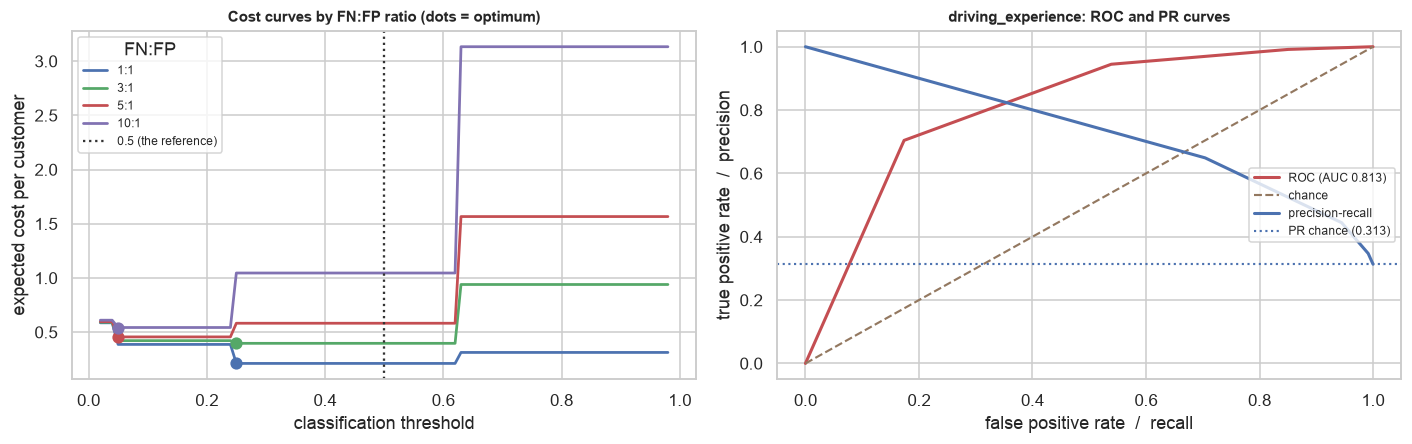

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

for r, color in zip([1, 3, 5, 10], ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]):
    costs = [expected_cost(y_val, p_de, t, r) for t in thresholds]
    axes[0].plot(thresholds, costs, label=f"{r}:1", color=color, lw=1.8)
    axes[0].plot(thresholds[np.argmin(costs)], min(costs), "o", color=color, ms=7)
axes[0].axvline(0.5, color="#333", ls=":", lw=1.5, label="0.5 (the reference)")
axes[0].set_xlabel("classification threshold"); axes[0].set_ylabel("expected cost per customer")
axes[0].set_title("Cost curves by FN:FP ratio (dots = optimum)", fontsize=10)
axes[0].legend(fontsize=8, title="FN:FP")

fpr, tpr, _ = roc_curve(y_val, p_de)
prec, rec, _ = precision_recall_curve(y_val, p_de)
axes[1].plot(fpr, tpr, color="#C44E52", lw=2, label=f"ROC (AUC {classification_metrics(y_val, p_de)['roc_auc']:.3f})")
axes[1].plot([0, 1], [0, 1], ls="--", color="#937860", lw=1.4, label="chance")
axes[1].plot(rec, prec, color="#4C72B0", lw=2, label="precision-recall")
axes[1].axhline(y_val.mean(), ls=":", color="#4C72B0", lw=1.4, label=f"PR chance ({y_val.mean():.3f})")
axes[1].set_xlabel("false positive rate  /  recall"); axes[1].set_ylabel("true positive rate  /  precision")
axes[1].set_title("driving_experience: ROC and PR curves", fontsize=10)
axes[1].legend(fontsize=8, loc="center right")

fig.tight_layout()
save_fig(fig, "cost_and_roc_curves")
plt.show()

The ROC curve is visibly stepped rather than smooth. That is not a plotting artifact:
`driving_experience` has four levels, so the model emits only four distinct
probabilities, and there are only four thresholds that do anything at all. A single
categorical feature buys a coarse instrument, which is worth the client knowing.

## 3. Under cost, the ranking changes completely

Notebook 03 found nine features with zero accuracy lift, two of which —
`speeding_violations` and `past_accidents` — rank risk well (AUC 0.732 and 0.726). They
were penalised for never crossing an arbitrary threshold. Freed from that threshold and
scored on cost, they get a fair hearing.

In [7]:
rows = []
for f, p in val_probs.items():
    costs = np.array([expected_cost(y_val, p, t, cfg.FN_TO_FP_COST_RATIO) for t in thresholds])
    rows.append({"feature": f, "optimal_threshold": thresholds[costs.argmin()],
                 "cost_at_optimum": costs.min(),
                 "cost_at_0.5": expected_cost(y_val, p, 0.5, cfg.FN_TO_FP_COST_RATIO),
                 "accuracy_at_0.5": (p >= 0.5).astype(int).__eq__(y_val).mean()})

# Trivial policies, for reference.
claim_rate = y_val.mean()
rows.append({"feature": "[always predict claim]", "optimal_threshold": np.nan,
             "cost_at_optimum": 1 - claim_rate, "cost_at_0.5": 1 - claim_rate,
             "accuracy_at_0.5": claim_rate})
rows.append({"feature": "[always predict no claim]", "optimal_threshold": np.nan,
             "cost_at_optimum": cfg.FN_TO_FP_COST_RATIO * claim_rate,
             "cost_at_0.5": cfg.FN_TO_FP_COST_RATIO * claim_rate,
             "accuracy_at_0.5": 1 - claim_rate})

cost_table = pd.DataFrame(rows).sort_values("cost_at_optimum").reset_index(drop=True)
cost_table.round(4)

,feature,optimal_threshold,cost_at_optimum,cost_at_0.5,accuracy_at_0.5
0,driving_experience,0.05,0.4567,0.5827,0.7880
1,past_accidents,0.26,0.5340,1.5667,0.6867
2,speeding_violations,0.32,0.5673,1.5667,0.6867
3,income,0.14,0.5827,1.0107,0.7547
4,age,0.16,0.5913,0.9040,0.7787
5,vehicle_ownership,0.02,0.6867,0.7940,0.7447
6,[always predict claim],NaN,0.6867,0.6867,0.3133
7,[always predict no claim],NaN,1.5667,1.5667,0.6867


Three things in that table are worth stopping on.

**`past_accidents` and `speeding_violations` are now second and third**, ahead of `age`
and `income`. Under accuracy they were indistinguishable from a model that predicts
nothing. Their information was always there; the metric could not see it.

**The baseline flips.** Under accuracy, "always predict no claim" scores 68.67% and
"always predict claim" scores 31.33%. Under a 5:1 cost ratio those reverse: always-claim
costs 0.687, always-no-claim costs 1.567. The majority-class baseline is not a fixed
property of the data — it depends on what you are optimising, and once costs are
asymmetric the reference's yardstick stops being the right one.

**Tuning the threshold matters more than picking the feature.** Moving
`speeding_violations` from 0.5 to its optimum cuts its cost from 1.567 to 0.567. That
single change is worth more than the entire gap between the best and worst feature in the
table.

## 4. What does the single-feature constraint cost?

The client asked for one feature because they have no infrastructure for anything larger.
That is a legitimate engineering constraint, and it has a price. Fitting one model with
every feature gives the ceiling.

`postal_code` is excluded: notebook 01 showed it perfectly separates 120 customers, and
including it would inflate the ceiling with an artifact.

In [8]:
multi_features = [f for f in cfg.FEATURES if f != "postal_code"]
p_multi_val = fit_predict(multi_features, va)

single_m = classification_metrics(y_val, p_de, baseline=baseline)
multi_m = classification_metrics(y_val, p_multi_val, baseline=baseline)

comparison = pd.DataFrame({
    "single feature (driving_experience)": single_m,
    f"all {len(multi_features)} features": multi_m,
}).T[["accuracy", "lift_over_baseline", "roc_auc", "precision", "recall", "brier"]]
comparison.round(4)

,accuracy,lift_over_baseline,roc_auc,precision,recall,brier
single feature (driving_experience),0.788,0.101286,0.812748,0.64902,0.704255,0.151967
all 15 features,0.848,0.161286,0.904518,0.788095,0.704255,0.110742


In [9]:
c_single = min(expected_cost(y_val, p_de, t, cfg.FN_TO_FP_COST_RATIO) for t in thresholds)
c_multi = min(expected_cost(y_val, p_multi_val, t, cfg.FN_TO_FP_COST_RATIO) for t in thresholds)
print(f"expected cost at 5:1, single feature : {c_single:.4f}")
print(f"expected cost at 5:1, all features   : {c_multi:.4f}")
print(f"the constraint costs {(c_single / c_multi - 1):.1%} more expected cost,")
print(f"{multi_m['accuracy'] - single_m['accuracy']:.4f} accuracy and {multi_m['roc_auc'] - single_m['roc_auc']:.4f} AUC.")

expected cost at 5:1, single feature : 0.4567
expected cost at 5:1, all features   : 0.3313
the constraint costs 37.8% more expected cost,
0.0600 accuracy and 0.0918 AUC.


The full model reaches 84.80% accuracy and an AUC of 0.905 on validation, against 78.80%
and 0.813 for the single feature.

**The one-feature constraint costs about 6 accuracy points, 0.09 AUC, and 38% higher
expected cost.** That is the honest answer to a question the client did not ask but
should want answered: this is what simplicity is buying you, priced. Whether it is worth
paying is their decision, not the analyst's — but they cannot make it without the number.

## 5. The test set

Everything above was decided on validation. One evaluation follows, on 1,500 customers no
model has seen and no decision has consulted.

Recommended configuration, fixed before this cell runs:

- **feature:** `driving_experience`
- **encoding:** dummy (3 parameters)
- **threshold:** 0.5 for the client's accuracy framing; 0.05 for the 5:1 cost framing,
  both chosen on validation
- **ceiling model:** all 15 features, for the constraint-cost comparison

In [10]:
y_test = test[cfg.TARGET].to_numpy()
p_de_test = fit_predict(["driving_experience"], te)
p_multi_test = fit_predict(multi_features, te)

final = []
for label, p, t in [
    ("driving_experience @ 0.5", p_de_test, 0.5),
    ("driving_experience @ 0.05 (cost-optimal)", p_de_test, 0.05),
    ("all features @ 0.5 (ceiling)", p_multi_test, 0.5),
    ("all features @ 0.16 (cost-optimal)", p_multi_test, 0.16),
]:
    m = classification_metrics(y_test, p, threshold=t, baseline=baseline)
    m["model"] = label
    m["expected_cost_5to1"] = expected_cost(y_test, p, t, cfg.FN_TO_FP_COST_RATIO)
    final.append(m)

final_df = pd.DataFrame(final).set_index("model")[
    ["accuracy", "baseline", "lift_over_baseline", "roc_auc",
     "precision", "recall", "expected_cost_5to1"]]
final_df.round(4)

,accuracy,baseline,lift_over_baseline,roc_auc,precision,recall,expected_cost_5to1
model,,,,,,,
driving_experience @ 0.5,0.7647,0.6867,0.0780,0.7938,0.6073,0.7043,0.6060
driving_experience @ 0.05 (cost-optimal),0.5993,0.6867,-0.0874,0.7938,0.4357,0.9447,0.4700
all features @ 0.5 (ceiling),0.8233,0.6867,0.1366,0.8778,0.7243,0.7043,0.5473
all features @ 0.16 (cost-optimal),0.7220,0.6867,0.0353,0.8778,0.5331,0.9085,0.3927


In [11]:
# Bootstrap interval on the headline number, on test.
n_te = len(y_test)
idx_te = rng.integers(0, n_te, size=(10_000, n_te))
correct = ((p_de_test >= 0.5).astype(int) == y_test).astype(float)
boot_te = correct[idx_te].mean(axis=1)

print(f"driving_experience, test accuracy      {correct.mean():.4f}")
print(f"  95% CI                               [{np.percentile(boot_te, 2.5):.4f}, {np.percentile(boot_te, 97.5):.4f}]")
print(f"  lift over the {baseline:.4f} baseline    {correct.mean() - baseline:+.4f}")
print(f"  lift 95% CI                          [{np.percentile(boot_te, 2.5) - baseline:+.4f}, {np.percentile(boot_te, 97.5) - baseline:+.4f}]")
print(f"  P(beats baseline)                    {((boot_te - baseline) > 0).mean():.4f}")
print()
print(f"validation accuracy was 0.7880; test is {correct.mean():.4f}, "
      f"a drop of {0.7880 - correct.mean():.4f}")

driving_experience, test accuracy      0.7647
  95% CI                               [0.7427, 0.7860]
  lift over the 0.6867 baseline    +0.0780
  lift 95% CI                          [+0.0560, +0.0993]
  P(beats baseline)                    1.0000

validation accuracy was 0.7880; test is 0.7647, a drop of 0.0233


### The final number

**`driving_experience` predicts car insurance claims with 76.47% accuracy on held-out
data, against a 68.67% majority-class baseline — a lift of 7.80 points, 95% CI
[+5.66, +9.93], beating the baseline in 10,000 of 10,000 bootstrap resamples.**

Two honest observations about that number.

**It is 2.3 points below the validation estimate of 78.80%.** That drop is expected and is
the reason the split exists. The winning feature was *chosen* on validation, so the
validation score carries selection optimism. The test number has no such contamination,
which is precisely why it is the one reported.

**It is also below the reference's 77.71%** — which was measured in-sample on all 10,000
rows, with no held-out data and no baseline stated. The comparison worth drawing is not
77.71% against 76.47%. It is 77.71% *presented as a result* against **+7.80 points of
measured, interval-bounded lift**. Those are different kinds of claim.

## 6. Summary

| Question | Answer |
|---|---|
| Which single feature? | `driving_experience` — but statistically tied with `age` |
| How good is it? | 76.47% test accuracy, +7.80 pts over baseline, CI [+5.7, +9.9] |
| Is the lift real? | Yes. 10,000 of 10,000 resamples beat the baseline |
| Is it better than `age`? | Cannot say. CI on the gap spans zero |
| What threshold? | Not 0.5. 0.25 at symmetric cost, 0.05 at 5:1 |
| Best feature under cost? | `driving_experience`, then `past_accidents` — which has *zero* accuracy lift |
| Cost of the one-feature rule? | ~6 accuracy points, 0.09 AUC, 38% higher expected cost |
| Should `postal_code` be used? | No. It separates an artifact and would not survive real data |

In [12]:
final_df.to_csv(cfg.DATA_PROCESSED / "results_final.csv")
cost_table.to_csv(cfg.DATA_PROCESSED / "results_cost_thresholds.csv", index=False)
ci.to_csv(cfg.DATA_PROCESSED / "results_bootstrap_ci.csv", index=False)
comparison.to_csv(cfg.DATA_PROCESSED / "results_single_vs_multi.csv")
print("wrote 4 result tables to data/processed/")

wrote 4 result tables to data/processed/
